### Building and Learning a Bayesian Network

Note that from our course we are subscribing to these notions:

**AI science:** define a probabilistic model, reason about its assumptions, and perform correct inference.

**AI engineering:** use a modern LLM to help translate a specification into executable code, then validate, test, and revise that code.

We will keep one Bayesian network throughout:

$$
C \rightarrow R,\qquad
C \rightarrow S,\qquad
R,S \rightarrow W,
$$

where

- $C$: Cloudy
- $R$: Rain
- $S$: Sprinkler
- $W$: WetGrass

The main engineering pipeline is

$$
\boxed{\text{natural-language specification}}
\rightarrow
\boxed{\text{LLM-generated code}}
\rightarrow
\boxed{\text{validation}}
\rightarrow
\boxed{\text{execution}}
\rightarrow
\boxed{\text{tests}}.
$$

The LLM will **not** replace Bayesian-network inference or parameter estimation. It will help generate the program that calls a probabilistic modelling library.

#### Setup

The notebook uses:

- `pgmpy` for Bayesian networks;
- `pandas` and `numpy` for data;
- `matplotlib` for plots;
- Hugging Face `transformers` for a local open-source coding LLM.

For the LLM we use:

```text
Qwen/Qwen2.5-Coder-7B-Instruct (15GB; not using this)
```

It is an instruction-tuned code model that can be loaded locally with Hugging Face Transformers.

Run the installation cell once if the packages are not already installed.

In [32]:
# Uncomment this line if these packages are not already installed.
# %pip install -q "pgmpy>=1.0" "transformers>=4.45" accelerate pandas matplotlib

In [33]:
import ast
import itertools
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

np.random.seed(7)

#### Let's start with this:
Before involving an LLM, we need a trusted mathematical specification.

The graph is

$$
C \rightarrow R,\qquad
C \rightarrow S,\qquad
R \rightarrow W,\qquad
S \rightarrow W.
$$

The joint distribution factorises as

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S).
$$

We use binary states:

$$
0=\text{False},\qquad 1=\text{True}.
$$

#### The probabilities

We will use the following parameters:

$$
P(C=1)=0.5.
$$

For Rain:

$$
P(R=1\mid C=0)=0.2,
\qquad
P(R=1\mid C=1)=0.8.
$$

For Sprinkler:

$$
P(S=1\mid C=0)=0.5,
\qquad
P(S=1\mid C=1)=0.1.
$$

For WetGrass:

$$
\begin{aligned}
P(W=1\mid R=0,S=0)&=0.01,\\
P(W=1\mid R=0,S=1)&=0.90,\\
P(W=1\mid R=1,S=0)&=0.90,\\
P(W=1\mid R=1,S=1)&=0.99.
\end{aligned}
$$

These numbers define the probabilistic model. The software must encode them without changing their meaning.

#### We trust ourself first (?). So, we implement a version ourself.

We first implement the network ourselves.

This is important because later the LLM-generated implementation needs something trustworthy to compare against.

For a binary variable, each `TabularCPD` has one row for state 0 and one row for state 1.

In [35]:
def build_reference_model():
    """Construct the trusted Sprinkler Bayesian network."""

    model = DiscreteBayesianNetwork([
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    ])

    # P(Cloudy)
    cpd_cloudy = TabularCPD(
        variable="Cloudy",
        variable_card=2,
        values=[
            [0.5],  # P(Cloudy=0)
            [0.5],  # P(Cloudy=1)
        ],
    )

    # P(Rain | Cloudy)
    # Columns correspond to Cloudy=0, Cloudy=1.
    cpd_rain = TabularCPD(
        variable="Rain",
        variable_card=2,
        values=[
            [0.8, 0.2],  # P(Rain=0 | Cloudy)
            [0.2, 0.8],  # P(Rain=1 | Cloudy)
        ],
        evidence=["Cloudy"],
        evidence_card=[2],
    )

    # P(Sprinkler | Cloudy)
    # Columns correspond to Cloudy=0, Cloudy=1.
    cpd_sprinkler = TabularCPD(
        variable="Sprinkler",
        variable_card=2,
        values=[
            [0.5, 0.9],  # P(Sprinkler=0 | Cloudy)
            [0.5, 0.1],  # P(Sprinkler=1 | Cloudy)
        ],
        evidence=["Cloudy"],
        evidence_card=[2],
    )

    # P(WetGrass | Rain, Sprinkler)
    # With evidence=["Rain", "Sprinkler"], columns are ordered as:
    # (Rain=0, Sprinkler=0),
    # (Rain=0, Sprinkler=1),
    # (Rain=1, Sprinkler=0),
    # (Rain=1, Sprinkler=1).
    cpd_wetgrass = TabularCPD(
        variable="WetGrass",
        variable_card=2,
        values=[
            [0.99, 0.10, 0.10, 0.01],  # WetGrass=0
            [0.01, 0.90, 0.90, 0.99],  # WetGrass=1
        ],
        evidence=["Rain", "Sprinkler"],
        evidence_card=[2, 2],
    )

    model.add_cpds(
        cpd_cloudy,
        cpd_rain,
        cpd_sprinkler,
        cpd_wetgrass,
    )

    return model

reference_model = build_reference_model()
print("Model valid:", reference_model.check_model())
print("Edges:", list(reference_model.edges()))

Model valid: True
Edges: [('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')]


#### Let's the CPDs

Do not treat the CPT representation as a formatting detail.

If the parent ordering or column ordering is wrong, the program can represent a different probability distribution even though the numerical values look familiar.

In [36]:
for cpd in reference_model.get_cpds():
    print(cpd)
    print()

+-----------+-----+
| Cloudy(0) | 0.5 |
+-----------+-----+
| Cloudy(1) | 0.5 |
+-----------+-----+

+---------+-----------+-----------+
| Cloudy  | Cloudy(0) | Cloudy(1) |
+---------+-----------+-----------+
| Rain(0) | 0.8       | 0.2       |
+---------+-----------+-----------+
| Rain(1) | 0.2       | 0.8       |
+---------+-----------+-----------+

+--------------+-----------+-----------+
| Cloudy       | Cloudy(0) | Cloudy(1) |
+--------------+-----------+-----------+
| Sprinkler(0) | 0.5       | 0.9       |
+--------------+-----------+-----------+
| Sprinkler(1) | 0.5       | 0.1       |
+--------------+-----------+-----------+

+-------------+--------------+--------------+--------------+--------------+
| Rain        | Rain(0)      | Rain(0)      | Rain(1)      | Rain(1)      |
+-------------+--------------+--------------+--------------+--------------+
| Sprinkler   | Sprinkler(0) | Sprinkler(1) | Sprinkler(0) | Sprinkler(1) |
+-------------+--------------+--------------+---------

### Exact inference

Suppose we observe that the grass is wet.

We want

$$
P(R=1\mid W=1).
$$

`VariableElimination` performs exact inference in this discrete Bayesian network. See below.

#### Variable elimination

Variable elimination is an **exact inference algorithm** for Bayesian networks.

Suppose we want to compute

$$
P(Rain \mid WetGrass=1).
$$

If our Bayesian network factorizes as

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S),
$$

then to compute the posterior over `Rain`, we keep the query variable $R$, fix the evidence $W=1$, and sum out the hidden variables $C$ and $S$:

$$
P(R,W=1)
=
\sum_C \sum_S
P(C)P(R\mid C)P(S\mid C)P(W=1\mid R,S).
$$

Variable elimination performs this efficiently by working with smaller factors instead of constructing the full joint distribution.

For example, we may eliminate $S$ first:

$$
\phi_1(C,R)
=
\sum_S
P(S\mid C)P(W=1\mid R,S).
$$

Then eliminate $C$:

$$
\phi_2(R)
=
\sum_C
P(C)P(R\mid C)\phi_1(C,R).
$$

Finally, normalize:

$$
P(R\mid W=1)
=
\frac{\phi_2(R)}
{\sum_R \phi_2(R)}.
$$

So the main idea is:

$$
\boxed{\text{multiply relevant factors}
\rightarrow
\text{sum out hidden variables}
\rightarrow
\text{normalize}}
$$

In `pgmpy`:

```python
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

result = inference.query(
    variables=["Rain"],
    evidence={"WetGrass": 1}
)

print(result)

In [38]:
inference = VariableElimination(reference_model)

posterior_rain = inference.query(
    variables=["Rain"],
    evidence={"WetGrass": 1},
    show_progress=True,
)

print(posterior_rain)
print("P(Rain=1 | WetGrass=1) =", posterior_rain.values[1])

+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.2952 |
+---------+-------------+
| Rain(1) |      0.7048 |
+---------+-------------+
P(Rain=1 | WetGrass=1) = 0.7047692307692307


#### Verify the library result independently

An engineering system should not rely on one implementation simply because it ran without raising an exception.

For this tiny network we can independently enumerate all $2^4=16$ assignments and compute the same posterior from the factorisation

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S).
$$

This gives us a small but valuable test oracle.

In [39]:
def p_cloudy(c):
    return 0.5


def p_rain(r, c):
    p_true = {0: 0.2, 1: 0.8}[c]
    return p_true if r == 1 else 1 - p_true


def p_sprinkler(s, c):
    p_true = {0: 0.5, 1: 0.1}[c]
    return p_true if s == 1 else 1 - p_true


def p_wetgrass(w, r, s):
    p_true = {
        (0, 0): 0.01,
        (0, 1): 0.90,
        (1, 0): 0.90,
        (1, 1): 0.99,
    }[(r, s)]
    return p_true if w == 1 else 1 - p_true


numerator = 0.0
denominator = 0.0

for c, r, s, w in itertools.product([0, 1], repeat=4):
    joint = (
        p_cloudy(c)
        * p_rain(r, c)
        * p_sprinkler(s, c)
        * p_wetgrass(w, r, s)
    )

    if w == 1:
        denominator += joint

        if r == 1:
            numerator += joint

posterior_by_enumeration = numerator / denominator

print("Enumeration:", posterior_by_enumeration)
print("pgmpy      :", posterior_rain.values[1])
print("Difference :", abs(posterior_by_enumeration - posterior_rain.values[1]))

Enumeration: 0.7047692307692309
pgmpy      : 0.7047692307692307
Difference : 2.220446049250313e-16


**Engineering principle:** a result can be syntactically valid and still be scientifically wrong. (Successful execution of a program is not an evidence of correctness.)

For this notebook, our trusted checks include:

- expected nodes and edges;
- `model.check_model()`;
- expected CPT dimensions;
- independently computed posterior probability.

### Bring in a local open-source LLM

We now give the same Bayesian-network specification to a coding LLM.

The LLM's job is to translate our natural-language specification into `pgmpy` code.

The LLM is **not** the inference engine.

The division of labour is:

```text
Natural-language BN specification
             |
             v
       coding LLM
             |
             v
       Python program
             |
             v
          pgmpy
             |
             v
 Bayesian-network inference
```

#### Load Qwen2.5-Coder-7B-Instruct (not using this here)

The first run downloads the model weights, so it requires internet access and disk space.

After the model is cached locally, later runs can reuse the cache.

On a CUDA workstation, `device_map="auto"` lets Transformers/Accelerate place the model automatically.

In [41]:
from transformers import pipeline

MODEL_ID = "Qwen/Qwen2.5-Coder-1.5B-Instruct" #(3GB) #"Qwen/Qwen2.5-Coder-7B-Instruct" #This one is about ~15GB

llm = pipeline(
    task="text-generation",
    model=MODEL_ID,
    device_map="auto",
    dtype="auto",
)

print("Loaded:", MODEL_ID)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded: Qwen/Qwen2.5-Coder-1.5B-Instruct


#### A small helper for deterministic code generation

For a classroom engineering example we prefer reproducibility over creative sampling.

Therefore we use `do_sample=False`.

In [42]:
def ask_coder(user_prompt, max_new_tokens=1400):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert Python programmer working with discrete "
                "Bayesian networks and the current pgmpy API. Follow the "
                "user specification exactly. Return concise executable code "
                "when code is requested."
            ),
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    output = llm(
        messages,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    # In chat mode, generated_text is a message list.
    return output[0]["generated_text"][-1]["content"]

### Ask the LLM to implement the network and inference

We will keep the prompt to be deliberately explicit.

This is already an engineering lesson: if we want generated software to implement a mathematical object, the specification must remove avoidable ambiguity.

In [43]:
inference_prompt = r"""
Write Python code using the current pgmpy API.

Construct this binary discrete Bayesian network:

Edges:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Use states 0=False and 1=True.

Probabilities:
P(Cloudy=1) = 0.5

P(Rain=1 | Cloudy=0) = 0.2
P(Rain=1 | Cloudy=1) = 0.8

P(Sprinkler=1 | Cloudy=0) = 0.5
P(Sprinkler=1 | Cloudy=1) = 0.1

P(WetGrass=1 | Rain=0, Sprinkler=0) = 0.01
P(WetGrass=1 | Rain=0, Sprinkler=1) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=0) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=1) = 0.99

Requirements:
- use DiscreteBayesianNetwork and TabularCPD;
- create a variable called generated_model;
- add all CPDs;
- call generated_model.check_model();
- use VariableElimination;
- compute P(Rain | WetGrass=1);
- store that query result in generated_posterior;
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

llm_inference_response = ask_coder(inference_prompt)
print(llm_inference_response)

Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


```python
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD

# Create a new Bayesian model
generated_model = BayesianModel()

# Define the edges of the Bayesian network
generated_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Define the CPDs for each node
cloudy_cpd = TabularCPD('Cloudy', 2, [[0.5], [0.5]])
rain_cpd = TabularCPD('Rain', 2, [[0.2, 0.8], [0.8, 0.2]], evidence=['Cloudy'], evidence_card=[2])
sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]], evidence=['Cloudy'], evidence_card=[2])
wet_grass_cpd = TabularCPD('WetGrass', 2, [
    [0.01, 0.90, 0.90, 0.01],
    [0.90, 0.01, 0.90, 0.90]
], evidence=['Rain', 'Sprinkler'], evidence_card=[2])

# Add the CPDs to the model
generated_model.add_cpds(cloudy_cpd, rain_cpd, sprinkler_cpd, wet_grass_cpd)

# Check if the model is valid
generated_model.check_model()

# Perform variable elimination to compute P(Rain |

#### Extract a Python code block

Models sometimes wrap code in Markdown fences even when asked not to.

The following helper removes a single outer code fence if present.

In [45]:
def extract_python_code(text):
    text = text.strip()

    match = re.search(r"```(?:python)?\s*(.*?)```", text, flags=re.DOTALL)
    if match:
        return match.group(1).strip()

    return text


generated_inference_code = extract_python_code(llm_inference_response)
print(generated_inference_code)

from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD

# Create a new Bayesian model
generated_model = BayesianModel()

# Define the edges of the Bayesian network
generated_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Define the CPDs for each node
cloudy_cpd = TabularCPD('Cloudy', 2, [[0.5], [0.5]])
rain_cpd = TabularCPD('Rain', 2, [[0.2, 0.8], [0.8, 0.2]], evidence=['Cloudy'], evidence_card=[2])
sprinkler_cpd = TabularCPD('Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]], evidence=['Cloudy'], evidence_card=[2])
wet_grass_cpd = TabularCPD('WetGrass', 2, [
    [0.01, 0.90, 0.90, 0.01],
    [0.90, 0.01, 0.90, 0.90]
], evidence=['Rain', 'Sprinkler'], evidence_card=[2])

# Add the CPDs to the model
generated_model.add_cpds(cloudy_cpd, rain_cpd, sprinkler_cpd, wet_grass_cpd)

# Check if the model is valid
generated_model.check_model()

# Perform variable elimination to compute P(Rain | WetGrass=

### Do not blindly execute generated code

An LLM can generate incorrect or unsafe code.

Before execution we will do two things:

- visually inspect the code;
- run a simple AST-based sanity check.

The check below is **not a secure Python sandbox**. It is only an instructional safeguard that rejects some obviously inappropriate constructs.

In [46]:
ALLOWED_IMPORT_PREFIXES = (
    "pgmpy",
    "numpy",
    "pandas",
)

FORBIDDEN_CALL_NAMES = {
    "eval",
    "exec",
    "compile",
    "open",
    "input",
    "__import__",
}


def basic_generated_code_check(source):
    tree = ast.parse(source)
    problems = []

    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                if not alias.name.startswith(ALLOWED_IMPORT_PREFIXES):
                    problems.append(f"Import not allowed: {alias.name}")

        if isinstance(node, ast.ImportFrom):
            module = node.module or ""
            if not module.startswith(ALLOWED_IMPORT_PREFIXES):
                problems.append(f"Import not allowed: {module}")

        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name):
            if node.func.id in FORBIDDEN_CALL_NAMES:
                problems.append(f"Forbidden call: {node.func.id}")

    return problems


problems = basic_generated_code_check(generated_inference_code)

if problems:
    print("Review required:")
    for problem in problems:
        print(" -", problem)
else:
    print("Basic check found no listed problems.")

Basic check found no listed problems.


#### Explicit approval before execution

Read the generated code above first.

Only after inspection, change

```python
APPROVE_GENERATED_CODE = False
```

to

```python
APPROVE_GENERATED_CODE = True
```

and rerun the cell.

In [47]:
APPROVE_GENERATED_CODE = False

generated_namespace = {}

if APPROVE_GENERATED_CODE:
    problems = basic_generated_code_check(generated_inference_code)

    if problems:
        raise RuntimeError(f"Generated code did not pass basic checks: {problems}")

    exec(generated_inference_code, generated_namespace)
    print("Generated code executed.")
else:
    print("Generated code NOT executed. Inspect it first, then set approval to True.")

Generated code NOT executed. Inspect it first, then set approval to True.


### Validate the LLM-generated Bayesian network

If the code was approved and executed, we test its mathematical content.

The important question is not

> Did Python run?

but

> Did the generated program implement the Bayesian network we specified?

In [48]:
def validate_generated_inference(namespace, reference_model, reference_posterior):
    if "generated_model" not in namespace:
        raise AssertionError("generated_model was not created.")

    if "generated_posterior" not in namespace:
        raise AssertionError("generated_posterior was not created.")

    model = namespace["generated_model"]
    posterior = namespace["generated_posterior"]

    expected_nodes = {"Cloudy", "Rain", "Sprinkler", "WetGrass"}
    expected_edges = {
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    }

    assert set(model.nodes()) == expected_nodes
    assert set(model.edges()) == expected_edges
    assert model.check_model()

    generated_value = float(posterior.values[1])
    reference_value = float(reference_posterior.values[1])

    assert np.isclose(generated_value, reference_value, atol=1e-10)

    return {
        "structure": "PASS",
        "check_model": "PASS",
        "posterior": generated_value,
        "reference": reference_value,
        "absolute_error": abs(generated_value - reference_value),
    }


if APPROVE_GENERATED_CODE:
    validation_report = validate_generated_inference(
        generated_namespace,
        reference_model,
        posterior_rain,
    )
    print(validation_report)
else:
    print("Run after approving and executing the generated code.")

Run after approving and executing the generated code.


**Key distinction:**

The LLM generated source code.

`pgmpy` represented the Bayesian network and performed variable elimination.

Our tests checked whether the generated program matched the scientific specification.

### Parameter estimation from data

So far, the CPT parameters were supplied by us.

Now assume the graph structure is known but the numerical CPT entries are not.

Given observations, we want to estimate parameters such as

$$
P(R=1\mid C=1).
$$

For complete discrete data, the maximum-likelihood estimate is based on relative frequencies. For example,

$$
\widehat{P}(R=1\mid C=1)
=
\frac{N(R=1,C=1)}{N(C=1)}.
$$

#### Generate synthetic data from the trusted model

Because this is a teaching example, we know the true generating model.

That means we can compare estimated CPTs with the true CPTs.

In [49]:
data_1000 = reference_model.simulate(
    n_samples=1000,
    seed=7,
    show_progress=False,
)

print(data_1000.head())
print("\nShape:", data_1000.shape)

  WetGrass Sprinkler Cloudy Rain
0        1         1      0    0
1        0         0      1    0
2        1         1      0    0
3        1         0      1    1
4        1         0      1    1

Shape: (1000, 4)


#### Estimate the CPTs by maximum likelihood

We keep the graph fixed and fit only the parameters.

In [50]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE

def make_empty_structure():
    return DiscreteBayesianNetwork([
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    ])

mle_model_1000 = make_empty_structure()

mle_model_1000.fit(
    data_1000,
    estimator=DiscreteMLE(),
)

print("Valid fitted model:", mle_model_1000.check_model())

for cpd in mle_model_1000.get_cpds():
    print(cpd)
    print()

Valid fitted model: True
+-----------+-------+
| Cloudy(0) | 0.512 |
+-----------+-------+
| Cloudy(1) | 0.488 |
+-----------+-------+

+---------+-------------+---------------------+
| Cloudy  | Cloudy(0)   | Cloudy(1)           |
+---------+-------------+---------------------+
| Rain(0) | 0.810546875 | 0.22745901639344263 |
+---------+-------------+---------------------+
| Rain(1) | 0.189453125 | 0.7725409836065574  |
+---------+-------------+---------------------+

+--------------+-----------+--------------------+
| Cloudy       | Cloudy(0) | Cloudy(1)          |
+--------------+-----------+--------------------+
| Sprinkler(0) | 0.5390625 | 0.9057377049180327 |
+--------------+-----------+--------------------+
| Sprinkler(1) | 0.4609375 | 0.0942622950819672 |
+--------------+-----------+--------------------+

+-------------+-----+--------------+
| Rain        | ... | Rain(1)      |
+-------------+-----+--------------+
| Sprinkler   | ... | Sprinkler(1) |
+-------------+-----+-------

#### Inspect one estimate directly from counts

Let us verify one CPT entry manually:

$$
\widehat{P}(R=1\mid C=1).
$$

In [51]:
cloudy_true = data_1000[data_1000["Cloudy"] == 1]

manual_mle = (
    (cloudy_true["Rain"] == 1).sum()
    / len(cloudy_true)
)

rain_cpd = mle_model_1000.get_cpds("Rain")
pgmpy_mle = float(rain_cpd.values[1, 1])

print("Manual estimate:", manual_mle)
print("pgmpy estimate :", pgmpy_mle)
print("True value     :", 0.8)

Manual estimate: 0.7725409836065574
pgmpy estimate : 0.7725409836065574
True value     : 0.8


### How does estimation change with sample size?

With finite data, estimated CPTs fluctuate around the true parameters.

As the sample size increases, we generally expect maximum-likelihood estimates to become more stable and approach the data-generating probabilities, assuming the data really come from this model and the regularity assumptions are satisfied.

We can see this empirically.

In [52]:
from pgmpy.parameter_estimator import DiscreteMLE

def fit_mle_from_n(n, seed=7):
    data = reference_model.simulate(
        n_samples=n,
        seed=seed,
        show_progress=False,
    )

    model = make_empty_structure()

    model.fit(
        data,
        estimator=DiscreteMLE(),
    )

    rain_cpd = model.get_cpds("Rain")

    # P(Rain=1 | Cloudy=1)
    estimate = float(
        rain_cpd.get_value(Rain=1, Cloudy=1)
    )

    return estimate


sample_sizes = [20, 50, 100, 500, 1000, 5000]

estimates = [
    fit_mle_from_n(n)
    for n in sample_sizes
]

result_table = pd.DataFrame({
    "N": sample_sizes,
    "estimated P(Rain=1 | Cloudy=1)": estimates,
})

result_table["absolute error"] = (
    result_table["estimated P(Rain=1 | Cloudy=1)"] - 0.8
).abs()

result_table

,N,estimated P(Rain=1 | Cloudy=1),absolute error
0,20,0.888889,0.088889
1,50,0.826087,0.026087
2,100,0.708333,0.091667
3,500,0.780488,0.019512
4,1000,0.772541,0.027459
5,5000,0.803961,0.003961


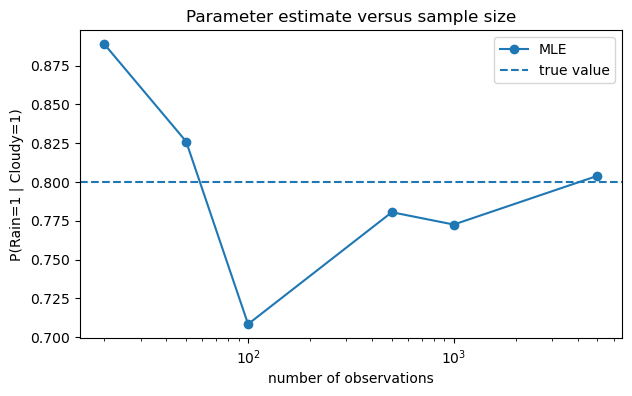

In [53]:
plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, estimates, marker="o", label="MLE")
plt.axhline(0.8, linestyle="--", label="true value")
plt.xscale("log")
plt.xlabel("number of observations")
plt.ylabel("P(Rain=1 | Cloudy=1)")
plt.title("Parameter estimate versus sample size")
plt.legend()
plt.show()

### Ask the LLM to write the parameter-estimation code

Now the engineering task changes.

The LLM receives:

- the known graph structure;
- the fact that a `pandas.DataFrame` called `data` already exists;
- the requirement to estimate CPTs by maximum likelihood.

Again, the statistical estimator is implemented by `pgmpy`. The LLM's role is to construct the correct program.

In [54]:
estimation_prompt = r"""
Write Python code using the current pgmpy API.

A pandas DataFrame named data already exists. Its columns are:
Cloudy, Rain, Sprinkler, WetGrass.
All variables use binary states 0 and 1.

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

The CPT parameters are unknown.

Requirements:
- use DiscreteBayesianNetwork;
- use MaximumLikelihoodEstimator;
- estimate all CPTs from data while keeping the graph fixed;
- store the fitted model in a variable called generated_mle_model;
- call generated_mle_model.check_model();
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

llm_estimation_response = ask_coder(estimation_prompt)
print(llm_estimation_response)

Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


```python
from pgmpy.models import BayesianModel
from pgmpy.estimators import MaximumLikelihoodEstimator
import pandas as pd

# Assuming data is already defined as per your requirements
data = pd.DataFrame({
    'Cloudy': [0, 1, 0, 1],
    'Rain': [1, 0, 1, 0],
    'Sprinkler': [0, 1, 0, 1],
    'WetGrass': [0, 0, 1, 1]
})

# Create a Bayesian Network object
generated_mle_model = BayesianModel()

# Add nodes to the model
generated_mle_model.add_nodes_from(['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Define edges based on the given structure
generated_mle_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Use Maximum Likelihood Estimator to estimate CPTs
mle = MaximumLikelihoodEstimator(generated_mle_model, data)
generated_mle_model.fit(mle)

# Check if the model is valid
generated_mle_model.check_model()
```

This code snippet creates a Bayesian Network, adds nodes, defines edges, fits the model using Maximum Likel

In [55]:
generated_estimation_code = extract_python_code(llm_estimation_response)
print(generated_estimation_code)

problems = basic_generated_code_check(generated_estimation_code)
print("\nBasic check:", problems if problems else "no listed problems")

from pgmpy.models import BayesianModel
from pgmpy.estimators import MaximumLikelihoodEstimator
import pandas as pd

# Assuming data is already defined as per your requirements
data = pd.DataFrame({
    'Cloudy': [0, 1, 0, 1],
    'Rain': [1, 0, 1, 0],
    'Sprinkler': [0, 1, 0, 1],
    'WetGrass': [0, 0, 1, 1]
})

# Create a Bayesian Network object
generated_mle_model = BayesianModel()

# Add nodes to the model
generated_mle_model.add_nodes_from(['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Define edges based on the given structure
generated_mle_model.add_edges_from([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Use Maximum Likelihood Estimator to estimate CPTs
mle = MaximumLikelihoodEstimator(generated_mle_model, data)
generated_mle_model.fit(mle)

# Check if the model is valid
generated_mle_model.check_model()

Basic check: no listed problems


#### Execute only after inspection

The generated code should use the provided DataFrame rather than inventing new data.

In [56]:
APPROVE_ESTIMATION_CODE = False

generated_estimation_namespace = {
    "data": data_1000.copy(),
}

if APPROVE_ESTIMATION_CODE:
    problems = basic_generated_code_check(generated_estimation_code)

    if problems:
        raise RuntimeError(f"Generated code did not pass basic checks: {problems}")

    exec(generated_estimation_code, generated_estimation_namespace)
    print("Generated estimation code executed.")
else:
    print("Generated code NOT executed. Inspect it first, then approve it.")

Generated code NOT executed. Inspect it first, then approve it.


#### Compare the LLM-generated fitted model with the trusted fit

For the same data and the same maximum-likelihood estimator, the fitted CPTs should agree numerically.

In [57]:
def cpd_value_map(model):
    """Flatten CPD arrays into a dictionary for easy numerical comparison."""
    result = {}

    for cpd in model.get_cpds():
        result[cpd.variable] = np.asarray(cpd.values, dtype=float)

    return result


def compare_models(model_a, model_b):
    a = cpd_value_map(model_a)
    b = cpd_value_map(model_b)

    variables = sorted(a)
    rows = []

    for variable in variables:
        diff = np.max(np.abs(a[variable] - b[variable]))
        rows.append({
            "variable": variable,
            "max absolute difference": diff,
        })

    return pd.DataFrame(rows)


if APPROVE_ESTIMATION_CODE:
    generated_mle_model = generated_estimation_namespace["generated_mle_model"]

    assert generated_mle_model.check_model()
    display(compare_models(mle_model_1000, generated_mle_model))
else:
    print("Run after approving the LLM-generated estimation code.")

Run after approving the LLM-generated estimation code.


### Sparse data and Bayesian parameter estimation

Maximum likelihood uses the observed counts directly.

With a small dataset, some parent-state configurations can be rare or even absent. This can produce unstable estimates or probabilities equal to 0 or 1 simply because the sample is small.

A Bayesian estimator adds prior pseudo-counts.

For a Dirichlet prior, the posterior parameter estimate can be viewed conceptually as

$$
\text{posterior counts}
=
\text{observed counts}
+
\text{prior pseudo-counts}.
$$

This is not a claim that one estimator is always better. It is a different modelling assumption that can regularise estimates when data are sparse.

In [58]:
from pgmpy.parameter_estimator import (
    DiscreteMLE,
    DiscreteBayesianEstimator,
)

data_small = reference_model.simulate(
    n_samples=30,
    seed=11,
    show_progress=False,
)

mle_small = make_empty_structure()
mle_small.fit(
    data_small,
    estimator=DiscreteMLE(),
)

bayes_small = make_empty_structure()
bayes_small.fit(
    data_small,
    estimator=DiscreteBayesianEstimator(
        prior_type="BDeu",
        equivalent_sample_size=10,
    ),
)

print("MLE Rain CPD")
print(mle_small.get_cpds("Rain"))

print("\nBayesian Rain CPD")
print(bayes_small.get_cpds("Rain"))

MLE Rain CPD
+---------+---------------------+---------------------+
| Cloudy  | Cloudy(0)           | Cloudy(1)           |
+---------+---------------------+---------------------+
| Rain(0) | 0.9473684210526315  | 0.09090909090909091 |
+---------+---------------------+---------------------+
| Rain(1) | 0.05263157894736842 | 0.9090909090909091  |
+---------+---------------------+---------------------+

Bayesian Rain CPD
+---------+---------------------+-----------+
| Cloudy  | Cloudy(0)           | Cloudy(1) |
+---------+---------------------+-----------+
| Rain(0) | 0.8541666666666666  | 0.21875   |
+---------+---------------------+-----------+
| Rain(1) | 0.14583333333333334 | 0.78125   |
+---------+---------------------+-----------+


#### Compare the small-sample estimates

The BDeu estimate incorporates a prior equivalent sample size.

We should interpret the difference scientifically:

- MLE reflects the empirical frequencies directly;
- Bayesian estimation combines data with the specified prior.

The prior is part of the model and should not be hidden as an implementation detail.

In [60]:
def rain_c1_probability(model):
    return float(model.get_cpds("Rain").values[1, 1])

comparison = pd.DataFrame({
    "method": ["True parameter", "MLE, N=30", "BDeu, N=30"],
    "P(Rain=1 | Cloudy=1)": [
        0.8,
        rain_c1_probability(mle_small),
        rain_c1_probability(bayes_small),
    ],
})

comparison

,method,P(Rain=1 | Cloudy=1)
0,True parameter,0.800000
1,"MLE, N=30",0.909091
2,"BDeu, N=30",0.781250


### Ask the LLM to revise MLE code to Bayesian estimation

This is a useful coding-assistant task because we already know the desired statistical change.

The LLM is asked to revise the implementation, while we remain responsible for checking whether the generated code actually uses the requested prior.

In [61]:
bayesian_prompt = r"""
A pandas DataFrame named data already exists with binary columns:
Cloudy, Rain, Sprinkler, WetGrass.

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Write Python code using the current pgmpy API to estimate all CPTs with BayesianEstimator.
Use:
prior_type="BDeu"
equivalent_sample_size=10

Requirements:
- keep the graph fixed;
- store the fitted model in generated_bayes_model;
- call generated_bayes_model.check_model();
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

llm_bayesian_response = ask_coder(bayesian_prompt)
print(llm_bayesian_response)

Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


```python
from pgmpy.estimators import BayesianEstimator
import pandas as pd

# Load your data into a pandas DataFrame
data = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your actual file path

# Create a BayesianEstimator object
estimator = BayesianEstimator(data, ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Fit the model with BDeu prior and equivalent sample size of 10
generated_bayes_model = estimator.fit(prior_type="BDeu", equivalent_sample_size=10)

# Check if the model is valid
generated_bayes_model.check_model()
```

This code snippet loads the data from a CSV file, creates a BayesianEstimator object with the specified prior type and equivalent sample size, fits the model to the data, checks the model for validity, and stores the fitted model in `generated_bayes_model`.


In [62]:
generated_bayesian_code = extract_python_code(llm_bayesian_response)
print(generated_bayesian_code)

problems = basic_generated_code_check(generated_bayesian_code)
print("\nBasic check:", problems if problems else "no listed problems")

from pgmpy.estimators import BayesianEstimator
import pandas as pd

# Load your data into a pandas DataFrame
data = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your actual file path

# Create a BayesianEstimator object
estimator = BayesianEstimator(data, ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Fit the model with BDeu prior and equivalent sample size of 10
generated_bayes_model = estimator.fit(prior_type="BDeu", equivalent_sample_size=10)

# Check if the model is valid
generated_bayes_model.check_model()

Basic check: no listed problems


### A deliberately broken Bayesian network

Validation matters even without an LLM.

Here we intentionally create an invalid CPT whose columns do not sum to 1.

The library should reject the model rather than silently using it.

In [63]:
broken_model = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
])

cpd_cloudy_ok = TabularCPD(
    variable="Cloudy",
    variable_card=2,
    values=[[0.5], [0.5]],
)

# Invalid: for Cloudy=0, 0.9 + 0.3 = 1.2.
cpd_rain_broken = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[
        [0.9, 0.2],
        [0.3, 0.8],
    ],
    evidence=["Cloudy"],
    evidence_card=[2],
)

broken_model.add_cpds(cpd_cloudy_ok, cpd_rain_broken)

try:
    broken_model.check_model()
except Exception as error:
    print("Validation caught the problem:")
    print(type(error).__name__ + ":", error)

Validation caught the problem:
ValueError: Sum or integral of conditional probabilities for node Rain is not equal to 1.


### A subtler failure: valid numbers, wrong semantics

Some mistakes are harder.

Imagine the four WetGrass probabilities are supplied in the wrong parent-state order.

Every column can still sum to 1, so `check_model()` may accept the CPD. Yet the model can represent the wrong distribution.

This is why we also need semantic tests such as known queries or independently calculated probabilities.

In [64]:
wrong_semantics_model = build_reference_model()

# Remove the correct WetGrass CPD.
wrong_semantics_model.remove_cpds(
    wrong_semantics_model.get_cpds("WetGrass")
)

# Deliberately permute the probabilities for the parent configurations.
wrong_wetgrass = TabularCPD(
    variable="WetGrass",
    variable_card=2,
    values=[
        [0.99, 0.10, 0.01, 0.10],
        [0.01, 0.90, 0.99, 0.90],
    ],
    evidence=["Rain", "Sprinkler"],
    evidence_card=[2, 2],
)

wrong_semantics_model.add_cpds(wrong_wetgrass)

print("check_model():", wrong_semantics_model.check_model())

wrong_inference = VariableElimination(wrong_semantics_model)
wrong_posterior = wrong_inference.query(
    ["Rain"],
    evidence={"WetGrass": 1},
    show_progress=False,
)

print("Correct posterior:", posterior_rain.values[1])
print("Wrong posterior  :", wrong_posterior.values[1])

check_model(): True
Correct posterior: 0.7047692307692307
Wrong posterior  : 0.7172952268709487


**This is the central science-engineering lesson:**

```text
Program runs
    !=
Probabilistic model is correct
    !=
Scientific assumptions are appropriate
```

The LLM can accelerate implementation, but it does not remove the need to understand the model.

### Turn validation into reusable tests

Instead of checking things manually every time, encode important expectations as tests.

In [65]:
def test_reference_model():
    model = build_reference_model()

    assert model.check_model()

    assert set(model.nodes()) == {
        "Cloudy", "Rain", "Sprinkler", "WetGrass"
    }

    assert set(model.edges()) == {
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    }

    infer = VariableElimination(model)
    posterior = infer.query(
        ["Rain"],
        evidence={"WetGrass": 1},
        show_progress=False,
    )

    assert np.isclose(
        posterior.values[1],
        posterior_by_enumeration,
        atol=1e-10,
    )


test_reference_model()
print("All reference tests passed.")

All reference tests passed.


### What exactly did the LLM contribute?

The notebook contains several different computational roles.

| Task | Component responsible |
|---|---|
| Interpret the natural-language programming request | LLM |
| Generate candidate Python code | LLM |
| Represent the Bayesian network | `pgmpy` |
| Check local BN consistency | `pgmpy.check_model()` |
| Perform exact inference | `VariableElimination` |
| Estimate CPTs from data | `MaximumLikelihoodEstimator` / `BayesianEstimator` |
| Decide whether generated code is acceptable | validation logic + human |
| Decide whether the statistical assumptions make sense | human / scientific reasoning |

This separation is important.

An LLM coding assistant can be useful without being treated as the source of probabilistic truth.

### An engineering view of the whole notebook

The complete loop is

```text
Bayesian-network theory
        |
        v
Natural-language specification
        |
        v
      LLM
        |
        v
Generated Python code
        |
        v
Static inspection / approval
        |
        v
      pgmpy
        |
        v
Inference or parameter estimation
        |
        v
Validation against mathematical expectations
        |
        +---- pass ----> use result
        |
        +---- fail ----> revise specification/code
```

The important point is that AI engineering does not mean abandoning the scientific model.

It means building a dependable software process around it.

### HW exercise: change the query

Without changing the network, ask the LLM to generate code for each query:

$$
P(S=1\mid W=1),
$$

$$
P(C=1\mid W=1),
$$

and

$$
P(R=1\mid W=1,S=0).
$$

Before running the generated code:

- identify the query variable;
- identify the evidence;
- predict qualitatively whether the posterior should increase or decrease;
- inspect the generated code;
- compare it with a trusted `VariableElimination` call.

In [31]:
# Trusted query examples for the exercise.
trusted_infer = VariableElimination(reference_model)

q_s = trusted_infer.query(
    ["Sprinkler"],
    evidence={"WetGrass": 1},
    show_progress=False,
)

q_c = trusted_infer.query(
    ["Cloudy"],
    evidence={"WetGrass": 1},
    show_progress=False,
)

q_r_given_w_s0 = trusted_infer.query(
    ["Rain"],
    evidence={"WetGrass": 1, "Sprinkler": 0},
    show_progress=False,
)

print("P(Sprinkler=1 | WetGrass=1) =", q_s.values[1])
print("P(Cloudy=1 | WetGrass=1) =", q_c.values[1])
print("P(Rain=1 | WetGrass=1, Sprinkler=0) =", q_r_given_w_s0.values[1])

P(Sprinkler=1 | WetGrass=1) = 0.4278461538461539
P(Cloudy=1 | WetGrass=1) = 0.5746153846153845
P(Rain=1 | WetGrass=1, Sprinkler=0) = 0.9922022048937886


### Classroom exercise: let the LLM explain its generated CPT

Ask the LLM:

> Explain exactly what each column of the WetGrass `TabularCPD` represents when `evidence=["Rain", "Sprinkler"]`. Do not change the code.

Then verify the explanation against the actual library convention and against the probabilities we specified.

This is useful because code generation and code explanation are different tasks, and either can be wrong.

### Classroom exercise: estimate from different datasets

Generate several datasets using different random seeds.

For each one:

- fit an MLE model;
- record $\widehat{P}(R=1\mid C=1)$;
- compare it with the true value $0.8$;
- ask the LLM to explain why different datasets produce different estimates.

The correct scientific explanation should refer to **sampling variability**, not to the LLM or to `pgmpy` being inconsistent.

In [ ]:
from pgmpy.parameter_estimator import DiscreteMLE

rows = []

for seed in [1, 2, 3, 4, 5]:
    data = reference_model.simulate(
        n_samples=100,
        seed=seed,
        show_progress=False,
    )

    fitted = make_empty_structure()

    fitted.fit(
        data,
        estimator=DiscreteMLE(),
    )

    rows.append({
        "seed": seed,
        "estimate": rain_c1_probability(fitted),
    })

pd.DataFrame(rows)

### Now, where could the system fail?

Potential failure modes include:

- the natural-language specification is ambiguous;
- the LLM uses an obsolete API;
- the LLM reverses a CPT row or parent ordering;
- generated code imports or calls something unintended;
- the code executes but represents the wrong distribution;
- the inference query uses the wrong evidence state;
- the dataset uses a different state encoding from the model;
- sparse data make parameter estimates unstable;
- a prior is introduced without being documented;
- a validation test checks only syntax and misses semantics.

The engineering response is not "trust the LLM more." It is to make the specification, validation, tests, and review process better.

### A compact evaluation rubric for LLM-generated BN code

For each generated program, check:

**Structure**

- correct variables;
- correct directed edges;
- acyclic graph.

**Parameters**

- each CPD is normalized;
- evidence variables are correct;
- parent-state ordering is correct;
- probabilities match the specification.

**Inference**

- correct query variable;
- correct evidence;
- posterior agrees with a trusted implementation or hand calculation.

**Parameter estimation**

- graph structure is not accidentally relearned;
- requested estimator is actually used;
- prior settings are explicit when Bayesian estimation is requested;
- estimates are compared on the same dataset.

**Software safety**

- generated code is inspected before execution;
- unnecessary file/network/system access is disallowed;
- model/library versions are recorded when reproducibility matters.

### Recap

The Bayesian network remains the scientific object:

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S).
$$

The LLM is an engineering assistant that can help translate specifications into code.

The reliable workflow is not

$$
\text{prompt}\rightarrow\text{LLM}\rightarrow\text{trust the answer}.
$$

It is

$$
\boxed{\text{specify}}
\rightarrow
\boxed{\text{generate}}
\rightarrow
\boxed{\text{inspect}}
\rightarrow
\boxed{\text{execute}}
\rightarrow
\boxed{\text{validate}}
\rightarrow
\boxed{\text{test}}.
$$

This gives a concrete connection between the two sides of the course:

**AI science:** what probability model should we use, and what inference/estimation is mathematically justified?

**AI engineering:** how do we use an LLM and software tools to implement that model without losing correctness, reproducibility, and control?

### References

For the probabilistic modelling side:

- D. Koller and N. Friedman, *Probabilistic Graphical Models: Principles and Techniques*, MIT Press, 2009.
- pgmpy documentation for discrete Bayesian networks, exact inference, and parameter estimation.

For the coding-model side:

- Qwen2.5-Coder technical report / model documentation.
- Hugging Face Transformers documentation for chat/text-generation pipelines.

The exact library APIs can evolve, which is another reason generated code should be tested against the installed library version.